In [1]:
from pymongo import MongoClient
from scipy import stats
from scipy.stats import chi2_contingency
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore') 

In [2]:
client = MongoClient("mongodb://localhost:27017/")
collection = client["lendingclub_db"]["loans_clean"]
df = pd.DataFrame(list(collection.find()))

# Drop the MongoDB internal _id column
df = df.drop(columns=["_id"])
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,5000,5000,4975.0,36,10.65,162.87,B,B2,unemployed,10,...,0.00,171.62,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0
1,2500,2500,2500.0,60,15.27,59.83,C,C4,ryder,0,...,1.11,119.66,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0
2,2400,2400,2400.0,36,15.96,84.33,C,C5,unemployed,10,...,0.00,649.91,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0
3,10000,10000,10000.0,36,13.49,339.31,C,C1,air resources board,10,...,0.00,357.48,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0
4,3000,3000,3000.0,60,12.69,67.79,B,B5,university medical group,1,...,0.00,67.79,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0


To Analyze:
1. Target variable distribution        ← bar chart, raw labels
2. Numeric distributions               ← histograms, log scale where needed
3. Correlation matrix heatmap          ← replaces all scatterplots
4. Grade/sub-grade vs default rate     ← heatmap
5. Employment length vs loan metrics   ← box plot
6. Grade and loan status               ← stacked bar (not pie)
7. Purpose vs loan status              ← stacked bar

In [3]:
df['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1984
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

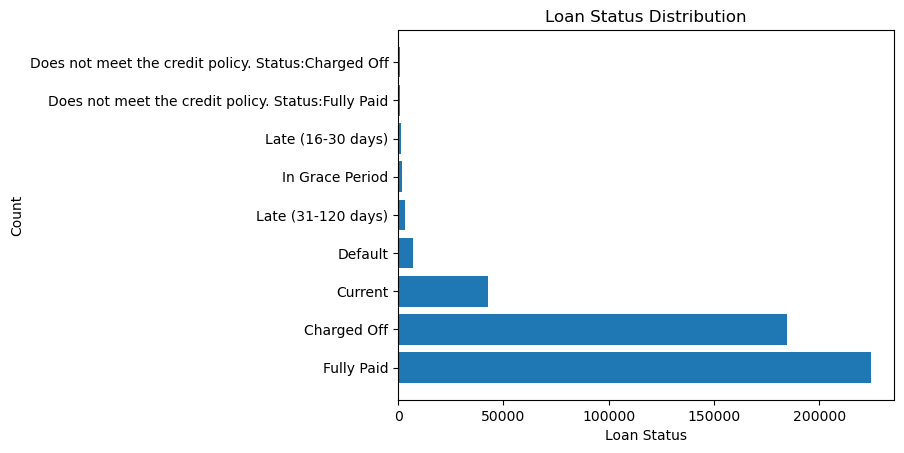

In [18]:
plt.barh(df['loan_status'].unique(), df['loan_status'].value_counts())
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

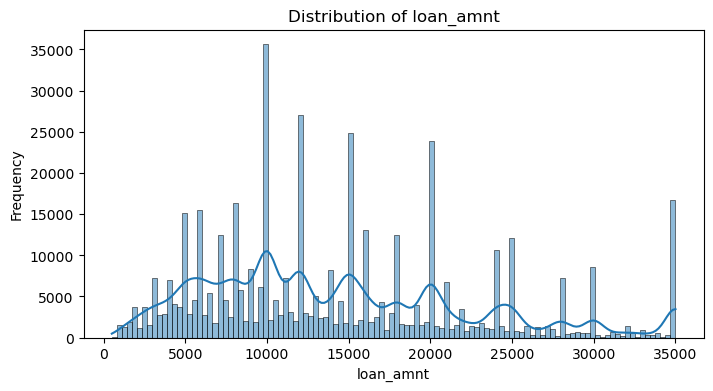

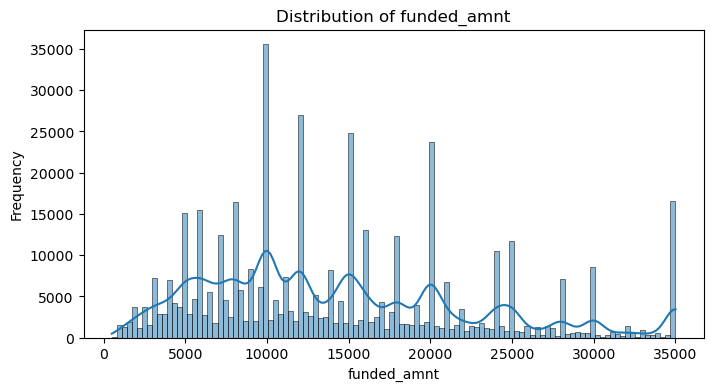

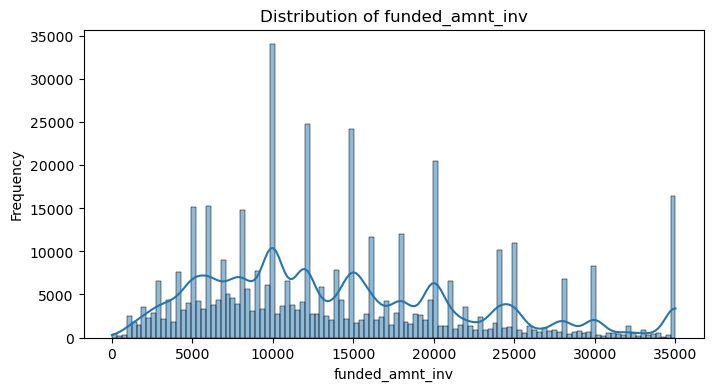

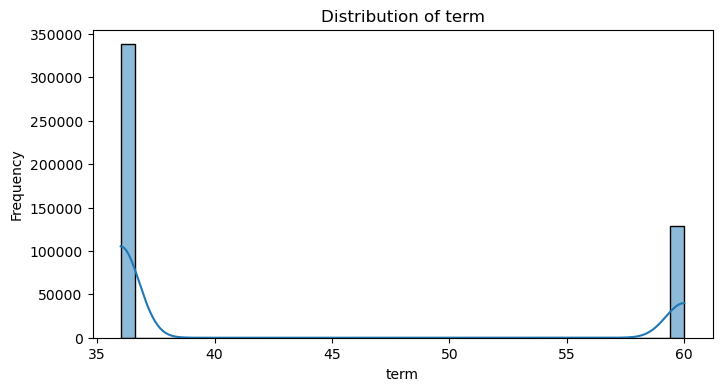

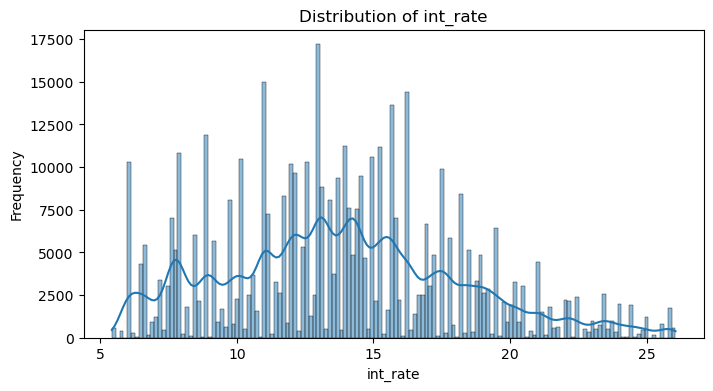

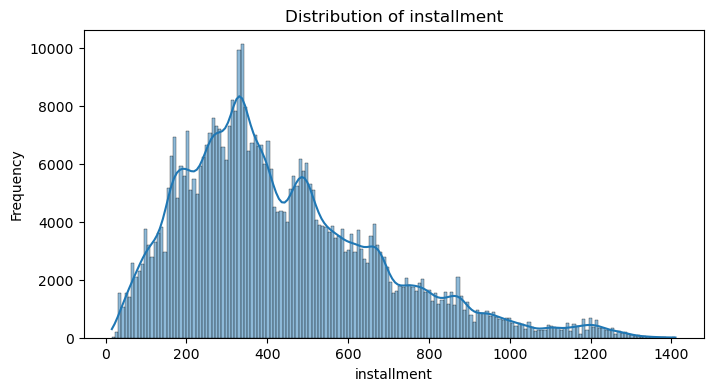

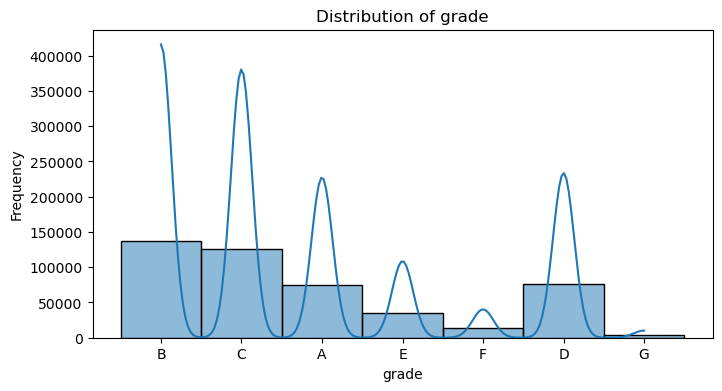

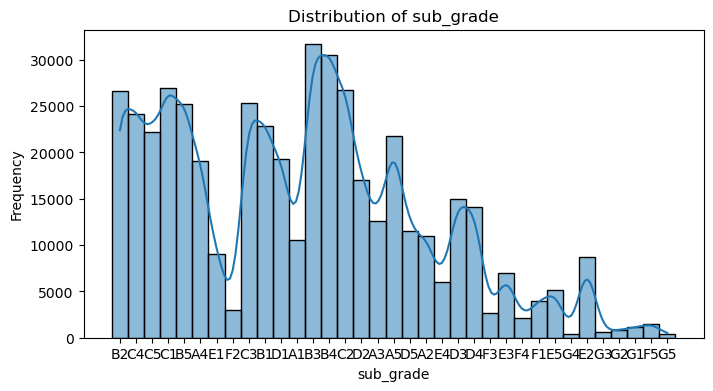

KeyboardInterrupt: 

In [ ]:
for col in df.columns:
    if df[col].dtype != 'object' or df[col].dtype != 'datetime64[ns]':
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

In [10]:
grade_a=df[df['grade']=='A']
grade_b=df[df['grade']=='B']
grade_c=df[df['grade']=='C']
grade_d=df[df['grade']=='D']
grade_e=df[df['grade']=='E']
grade_f=df[df['grade']=='F']
grade_g=df[df['grade']=='G']


In [8]:
df['loan_status'].unique()

array(['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

([<matplotlib.patches.Wedge at 0x22cb157aa80>,
 [Text(0.04506361230266004, 1.0990765536786942, 'Fully Paid'),
  Text(-0.19257893090684725, -1.083011244341801, 'Charged Off'),
  Text(1.0852483998386195, -0.179543617674692, 'Current'),
  Text(1.0989363879404532, -0.048361299200807714, 'Default'),
  Text(1.0997175866107556, -0.024924479914644155, 'Late (31-120 days)'),
  Text(1.0999251528327398, -0.012831919804688936, 'In Grace Period'),
  Text(1.099982609049578, -0.006185449739809044, 'Late (16-30 days)'),
  Text(1.0999979511740698, -0.002123066849810366, 'Does not meet the credit policy. Status:Fully Paid'),
  Text(1.0999999380850305, -0.0003690703582719523, 'Does not meet the credit policy. Status:Charged Off')],
 [Text(0.024580152165087292, 0.5994963020065605, '49%'),
  Text(-0.10504305322191666, -0.5907334060046187, '47%'),
  Text(0.5919536726392469, -0.09793288236801383, '3%'),
  Text(0.5994198479675198, -0.02637889047316784, '0%'),
  Text(0.5998459563331393, -0.013595170862533174, 

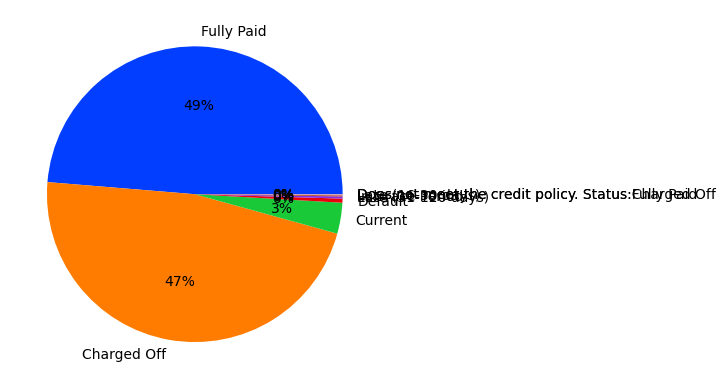

In [ ]:
data_a = grade_a['loan_status'].value_counts()
data_b = grade_b['loan_status'].value_counts()
data_c = grade_c['loan_status'].value_counts()
data_d = grade_d['loan_status'].value_counts()
data_e = grade_e['loan_status'].value_counts()
data_f = grade_f['loan_status'].value_counts()
data_g = grade_g['loan_status'].value_counts()
mylabels = ['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off']
sns.pairplot()